In [9]:
from sklearn.datasets import make_regression

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [10]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

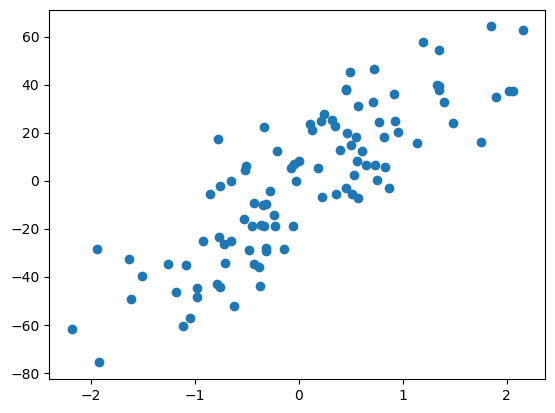

In [15]:
plt.scatter(X,y)

In [17]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


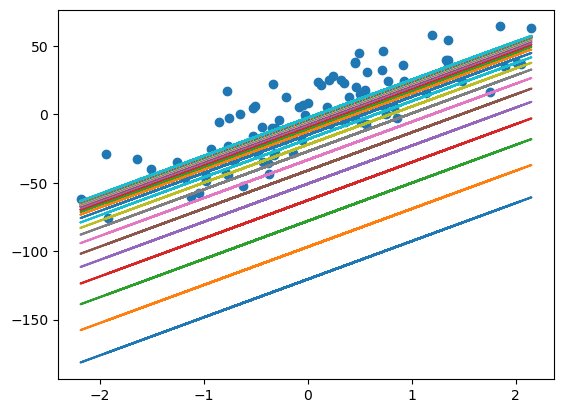

In [19]:
b = -150
m = 27.82
lr = 0.001
all_b = []
all_cost = []

epochs = 30

for i in range(epochs):
    slop = 0
    cost  = 0
    for j in range(X.shape[0]):
        slop = slop - 2 * (y[j] - (m * X[j]) - b)
        cost = cost + (y[j] - m * X[j] - b) ** 2

    b = b - (lr * slop)
    all_b.append(b)
    all_cost.append(cost)
    y_pred = m * X + b
    plt.plot(X,y_pred)

plt.scatter(X,y)
    

In [22]:
all_b = np.array(all_b).ravel()
all_b

array([-120.4588544 ,  -96.82593791,  -77.91960473,  -62.79453818,
        -50.69448494,  -41.01444235,  -33.27040827,  -27.07518102,
        -22.11899921,  -18.15405376,  -14.98209741,  -12.44453232,
        -10.41448025,   -8.7904386 ,   -7.49120528,   -6.45181862,
         -5.62030929,   -4.95510183,   -4.42293586,   -3.99720308,
         -3.65661686,   -3.38414789,   -3.16617271,   -2.99179256,
         -2.85228845,   -2.74068515,   -2.65140252,   -2.57997641,
         -2.52283553,   -2.47712282])

In [25]:
all_cost = np.array(all_cost).ravel()
all_cost

array([2210040.49020261, 1424629.13499295,  921965.86765877,
        600261.37656489,  394370.50226481,  262600.34271276,
        178267.44059944,  124294.38324692,   89751.62654131,
         67644.26224972,   53495.5491031 ,   44440.37268926,
         38645.05978441,   34936.0595253 ,   32562.29935947,
         31043.09285334,   30070.80068942,   29448.5337045 ,
         29050.28283416,   28795.40227714,   28632.27872065,
         28527.87964449,   28461.06423575,   28418.30237416,
         28390.93478274,   28373.41952423,   28362.20975879,
         28355.0355089 ,   28350.44398898,   28347.50541622])

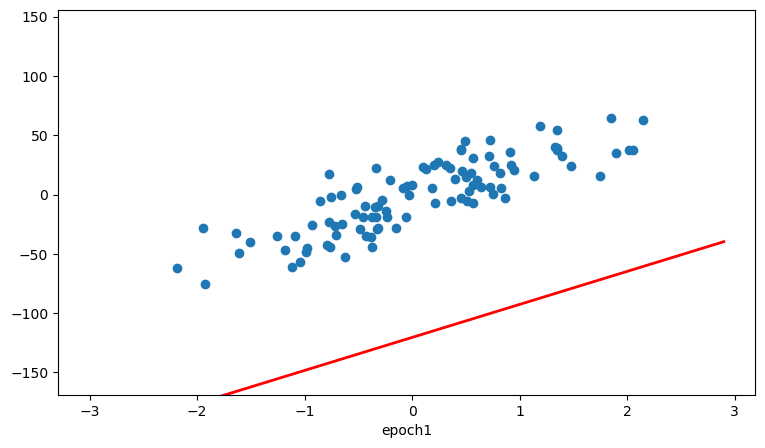

In [30]:
fig ,ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3,3,0.1)
y_i = x_i * m -150
ax.scatter(X,y)
line, = ax.plot(x_i, x_i*50 - 4, 'r-', linewidth=2)

def update(i):
    label = 'epoch{0}'.format(i + 1)
    line.set_ydata(x_i * m + all_b[i])
    ax.set_xlabel(label)

anim = FuncAnimation(fig, update, repeat=True, frames=epochs, interval=50)

#f = r"animation.gif" 
#writergif = animation.PillowWriter(fps=2) 
#anim.save(f, writer=writergif)


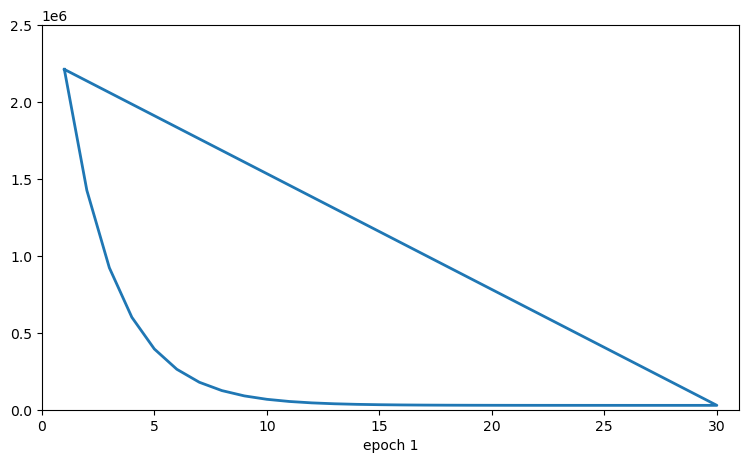

In [32]:
# creating a blank window 
# for the animation 
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(0, 2500000)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 

num_epochs = list(range(1, 31))
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_cost[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation1.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

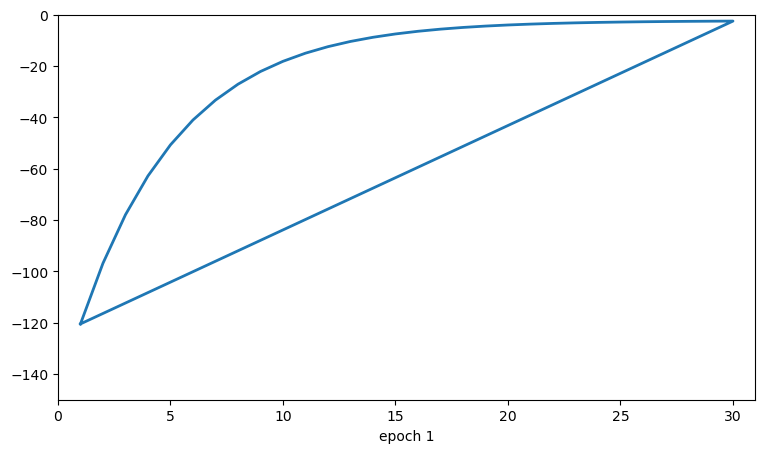

In [33]:
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(0, 31), ylim =(-150, 0)) 
  
line, = axis.plot([], [], lw = 2) 
  
xdata, ydata = [], [] 


num_epochs = list(range(1, 31))
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(num_epochs[i]) 
    ydata.append(all_b[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 30,repeat=False, interval = 500)

f = r"animation2.gif" 
writergif = animation.PillowWriter(fps=2) 
anim.save(f, writer=writergif)

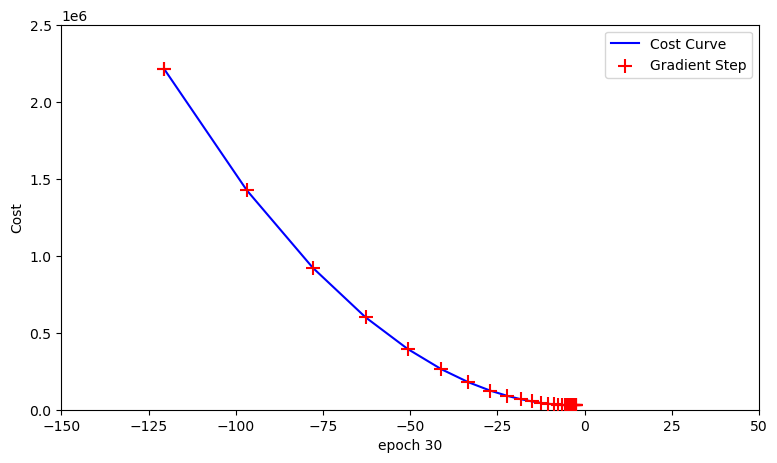

In [35]:
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np


# Figure aur Axes initialize karein
fig, ax = plt.subplots(figsize=(9, 5))

# Cost curve plot karein
ax.plot(all_b, all_cost, color='blue', label='Cost Curve')

# Scatter object initialize (khali points ke saath)
sc = ax.scatter([], [], color='red', marker='+', s=100, zorder=5, label='Gradient Step')

# Limits aur Labels set karein
ax.set_xlim(-150, 50)
ax.set_ylim(0, 2500000)
ax.set_ylabel('Cost')
ax.legend()

x, y = [], []

# Animation Update Function
def animate(i):
    label = f'epoch {i + 1}'
    x.append(all_b[i])
    y.append(all_cost[i])
    
    # Red '+' marks ke coordinates 
    sc.set_offsets(np.column_stack((x, y)))
    ax.set_xlabel(label)
    return sc, ax

# Animation create karein
ani = animation.FuncAnimation(fig, animate, frames=len(all_b), interval=500, repeat=True)

# GIF save karein
f = r"animation3.gif"
writergif = animation.PillowWriter(fps=2)
ani.save(f, writer=writergif)

plt.show()

In [41]:
b_input = np.linspace(-150,150,100)

In [45]:

cost_input = []

for i in range(len(b_input)):
    this_cost = 0 
    for j in range(X.shape[0]):
        this_cost = this_cost + (y[j] - m*X[j] - b_input[i])**2
    #cost_input.append(this_cost)
    print(this_cost)
        

IndexError: list index out of range